In [1]:
import uproot
import numpy as np
import os, tempfile
import awkward as ak
_orig_vstack = np.__dict__.get('_orig_vstack', np.vstack)  # Save original if not saved already
def _patched_vstack(arrays, dtype=None):
    stacked = _orig_vstack(arrays)
    return stacked.astype(dtype) if dtype is not None else stacked

np.vstack = _patched_vstack

import CLUEstering as clue
import pandas as pd

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


In [10]:
in_path  = "mult_e.root"
out_path = "mult_e_withLC.root"

# CLUE parameters (tune later; ensure units are consistent with your x,y and energy)
DC   = 1.3
RHOC = 9.0
DM   = 2.6
PPB  = 10  # pointsPerBin (optional; defaults to 10)
BACKEND = "cpu serial"  # or "cpu tbb", "gpu cuda", "gpu hip" if available

In [11]:
# Cell 2: inspect file and auto-detect the tree containing the hit branches
required_hit_branches = {"hit_x", "hit_y", "hit_Edep", "hit_layer"}

with uproot.open(in_path) as f:
    print("File keys:")
    for k in f.keys():
        print("  ", k)

    # Try to find a TTree that has all required branches
    tree_name = None
    for k in f.keys():
        try:
            t = f[k]
            if hasattr(t, "keys"):
                if required_hit_branches.issubset(set(t.keys())):
                    tree_name = k
                    break
        except Exception:
            pass

    if tree_name is None:
        raise RuntimeError("Could not find a TTree with required hit branches. Check the file structure.")
    else:
        print("\nUsing TTree:", tree_name)
        t = f[tree_name]
        print("Branches present:", list(t.keys()))
        print("Events:", t.num_entries)


File keys:
   HGCALTBout;1

Using TTree: HGCALTBout;1
Branches present: ['edep', 'CEETot', 'CHETot', 'AHCALTot', 'HGCALTot', 'IntLayer', 'PDGID', 'PrimaryEnergy', 'CEEIntLayer', 'CHEIntLayer', 'CEESignals', 'CHESignals', 'AHCALSignals', 'hit_x', 'hit_y', 'hit_z', 'hit_Edep', 'hit_trackid', 'hit_showerid', 'hit_detector', 'hit_layer', 'CEEHitCount', 'PrimaryEnergies', 'PrimaryPDGIDs']
Events: 5.0


In [12]:
# Cell 4: produce the flat LC table (one row per layer-cluster)

# --- CMSSW-like parameter defaults (use existing globals if already set earlier) ---
BACKEND = globals().get("BACKEND", "cpu serial")
PPB     = globals().get("PPB", 10)
KAPPA   = globals().get("KAPPA", 9.0)  # CMSSW default kappa

def dc_for_layer(layer_id: int) -> float:
    # Reproduce CMSSW vecDeltas: 1.3 for silicon, 0.0315 for scintillator.
    # Adjust the boundary if your geometry differs.
    return 1.3 if layer_id <= 40 else 0.0315

def estimate_rhoc(x: np.ndarray, y: np.ndarray, w: np.ndarray, dc: float, kappa: float = KAPPA) -> float:
    # Robust σ of layer density using a dc-scale grid approximation, then rhoc = kappa * sigma_rho.
    if x.size == 0:
        return 0.0
    eps = 1e-6
    bx = np.floor((x - x.min()) / max(dc, eps)).astype(np.int32)
    by = np.floor((y - y.min()) / max(dc, eps)).astype(np.int32)
    keys = (bx.astype(np.int64) << 32) | (by.astype(np.int64) & 0xffffffff)
    df_bw = pd.DataFrame({"k": keys, "w": w})
    bw = df_bw.groupby("k", sort=False)["w"].sum().to_dict()

    rho = np.empty(x.size, dtype=np.float32)
    for i in range(x.size):
        sx = int(bx[i]); sy = int(by[i])
        s = 0.0
        for dx_ in (-1, 0, 1):
            for dy_ in (-1, 0, 1):
                k = (np.int64(sx + dx_) << 32) | (np.int64(sy + dy_) & 0xffffffff)
                s += bw.get(k, 0.0)
        rho[i] = s

    med = float(np.median(rho))
    mad = float(np.median(np.abs(rho - med)))
    sigma_rho = 1.4826 * mad
    return float(kappa * sigma_rho)

def run_clue_layer(x: np.ndarray, y: np.ndarray, w: np.ndarray,
                   dc: float, rhoc: float, backend: str = BACKEND, ppb: int = PPB) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32).ravel()
    y = np.asarray(y, dtype=np.float32).ravel()
    w = np.asarray(w, dtype=np.float32).ravel()

    dm = 2.0 * dc  # CMSSW: outlierDeltaFactor_ = 2

    clust = clue.clusterer(float(dc), float(rhoc), float(dm), int(ppb))
    clust.read_data({"x0": x.tolist(), "x1": y.tolist(), "weight": w.tolist()})
    clust.run_clue(backend)

    with tempfile.TemporaryDirectory() as td:
        out_csv = os.path.join(td, "layer_results.csv")
        clust.to_csv(td + "/", "layer_results.csv")
        df = pd.read_csv(out_csv)
    if "cluster_ids" not in df.columns:
        raise RuntimeError("CLUE CSV missing 'cluster_ids'. Package version may differ.")
    return df["cluster_ids"].to_numpy(dtype=np.int32)

with uproot.open(in_path) as f:
    t = f[tree_name]

    X = t["hit_x"].array()       # jagged: [event][hit]
    Y = t["hit_y"].array()
    E = t["hit_Edep"].array()
    L = t["hit_layer"].array()

    n_events = len(X)
    print("Events:", n_events)

    LC = {k: [] for k in [
        "event", "layer", "lc_id",
        "energy", "x", "y",
        "cov_xx", "cov_xy", "cov_yy",
        "nhits", "is_seed_frac"
    ]}

    per_event_labels = []

    for ev in range(n_events):
        x_ev = np.asarray(X[ev], dtype=np.float32)
        y_ev = np.asarray(Y[ev], dtype=np.float32)
        e_ev = np.asarray(E[ev], dtype=np.float32)
        l_ev = np.asarray(L[ev], dtype=np.int32)

        labels_ev = np.full(x_ev.shape[0], -1, dtype=np.int32)

        for lyr in np.unique(l_ev):
            idx = np.where(l_ev == lyr)[0]
            if idx.size == 0:
                continue

            x = x_ev[idx]; y = y_ev[idx]; w = e_ev[idx]

            dc = dc_for_layer(int(lyr))
            rhoc = estimate_rhoc(x, y, w, dc, kappa=KAPPA)

            lbl = run_clue_layer(x, y, w, dc=dc, rhoc=rhoc, backend=BACKEND, ppb=PPB)

            if lbl.shape[0] != idx.shape[0]:
                raise RuntimeError("Size mismatch between labels and layer hit selection.")

            valid = lbl >= 0
            mapped = np.full(lbl.shape, -1, dtype=np.int32)
            if np.any(valid):
                old_ids = np.unique(lbl[valid])
                id_map = {old: i for i, old in enumerate(old_ids)}
                mapped[valid] = np.vectorize(id_map.get)(lbl[valid]).astype(np.int32)

                for cid in range(mapped.max() + 1):
                    m = mapped == cid
                    xe, ye, we = x[m], y[m], w[m]
                    W = float(np.sum(we))
                    if W <= 0.0:
                        x0 = y0 = 0.0
                        cxx = cxy = cyy = 0.0
                    else:
                        x0 = float(np.sum(we * xe) / W)
                        y0 = float(np.sum(we * ye) / W)
                        dx = xe - x0; dy = ye - y0
                        cxx = float(np.sum(we * dx * dx) / W)
                        cxy = float(np.sum(we * dx * dy) / W)
                        cyy = float(np.sum(we * dy * dy) / W)

                    LC["event"].append(int(ev))
                    LC["layer"].append(int(lyr))
                    LC["lc_id"].append(int(cid))
                    LC["energy"].append(W)
                    LC["x"].append(x0)
                    LC["y"].append(y0)
                    LC["cov_xx"].append(cxx)
                    LC["cov_xy"].append(cxy)
                    LC["cov_yy"].append(cyy)
                    LC["nhits"].append(int(np.count_nonzero(m)))

                    if W > 0 and np.any(m):
                        iseed = int(np.argmax(we))
                        LC["is_seed_frac"].append(float(we[iseed] / W))
                    else:
                        LC["is_seed_frac"].append(0.0)

            labels_ev[idx] = mapped

        per_event_labels.append(labels_ev)

print("Built LC rows:", len(LC["event"]))


Events: 5
Built LC rows: 165


In [13]:
# Cell 5: write out mult_5_pi_withLC.root with LC tree appended
if os.path.exists(out_path):
    os.remove(out_path)

with uproot.open(in_path) as fin, uproot.recreate(out_path) as fout:
    # Copy all original TTrees (and other writable objects)
    for key in fin.keys():
        obj = fin[key]
        try:
            if hasattr(obj, "keys"):  # TTree-like
                fout[key] = {br: obj[br].array() for br in obj.keys()}
            else:
                # Try to write histos or other objects if supported; skip if not
                fout[key] = obj
        except Exception:
            print("Skipped non-writable object:", key)

    # Add the LC tree
    LC_schema = {
        "event":   "int32",
        "layer":   "int16",
        "lc_id":   "int32",
        "energy":  "float64",
        "x":       "float32",
        "y":       "float32",
        "cov_xx":  "float32",
        "cov_xy":  "float32",
        "cov_yy":  "float32",
        "nhits":   "int32",
        "is_seed_frac": "float32",
    }
    fout.mktree("LC", LC_schema)
    fout["LC"].extend(LC)

print("Wrote:", out_path)


Wrote: mult_e_withLC.root


In [14]:
# Cell 6: verify LC contents
with uproot.open(out_path) as f:
    print("Keys:", list(f.keys()))
    lc = f["LC"]
    print("LC rows:", lc.num_entries)
    # Peek first 10
    small = {k: lc[k].array()[:10] for k in lc.keys()}
small


Keys: ['HGCALTBout;1;1', 'LC;1']
LC rows: 165


{'event': <Array [0, 0, 0, 0, 0, 0, 0, 0, 0, 0] type='10 * int32'>,
 'layer': <Array [1, 2, 4, 4, 4, 5, 6, 6, 6, 7] type='10 * int16'>,
 'lc_id': <Array [0, 0, 0, 1, 2, 0, 0, 1, 2, 0] type='10 * int32'>,
 'energy': <Array [0.126, 0.502, 0.0332, ... 6.32, 11.6] type='10 * float64'>,
 'x': <Array [0.316, 0.346, -6.72, ... 0.312, 0.308] type='10 * float32'>,
 'y': <Array [7.29, 7.25, 16.8, ... 4.68, 7.25, 7.3] type='10 * float32'>,
 'cov_xx': <Array [0.00255, 0.00111, 0, ... 0, 0.159, 0.4] type='10 * float32'>,
 'cov_xy': <Array [-0.00911, 0.00445, ... -0.0808] type='10 * float32'>,
 'cov_yy': <Array [0.0326, 0.0407, 0, ... 0, 0.227, 0.252] type='10 * float32'>,
 'nhits': <Array [3, 12, 1, 167, 1, ... 16, 1, 235, 398] type='10 * int32'>,
 'is_seed_frac': <Array [0.341, 0.162, 1, ... 1, 0.0188, 0.0126] type='10 * float32'>}

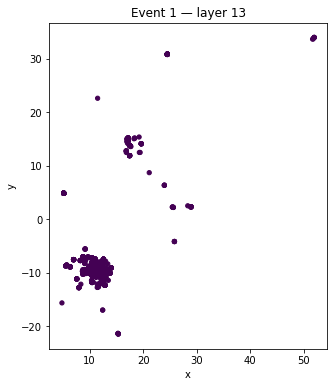

In [17]:
# Cell 7: simple plot to eyeball clusters on a chosen event & layer
event_idx = 1
layer_idx = 13 # set an integer to filter to one layer (e.g., 12)

with uproot.open(in_path) as f:
    t = f[tree_name]
    x = np.asarray(t["hit_x"].array()[event_idx], dtype=float)
    y = np.asarray(t["hit_y"].array()[event_idx], dtype=float)
    L = np.asarray(t["hit_layer"].array()[event_idx], dtype=int)

labels = per_event_labels[event_idx]

mask = (L == layer_idx) if layer_idx is not None else np.ones_like(L, dtype=bool)
plt.figure(figsize=(6,6))
plt.scatter(x[mask], y[mask], c=labels[mask], s=18)
plt.gca().set_aspect("equal")
plt.xlabel("x"); plt.ylabel("y")
plt.title(f"Event {event_idx} — layer {layer_idx if layer_idx is not None else 'all'}")
plt.show()


Event 4 has 6 layer-clusters.


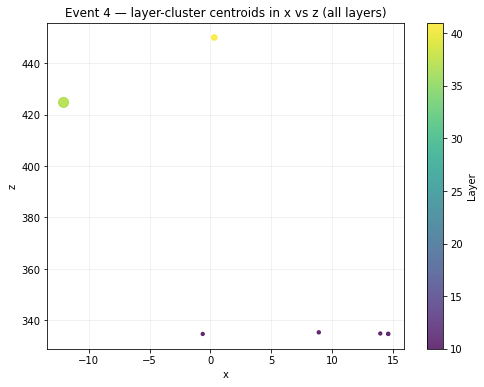

In [36]:
# Cell 7: plot layer-cluster centroids in x–z across all layers for one event
event_idx = 4  # choose the event to visualize

with uproot.open(in_path) as f:
    t = f[tree_name]
    x = np.asarray(t["hit_x"].array()[event_idx], dtype=float)
    y = np.asarray(t["hit_y"].array()[event_idx], dtype=float)  # not used here, but kept if you want to extend
    L = np.asarray(t["hit_layer"].array()[event_idx], dtype=int)
    E = np.asarray(t["hit_Edep"].array()[event_idx], dtype=float)

    # Prefer true z if available; else use layer index as z proxy
    if "hit_z" in t.keys():
        Z = np.asarray(t["hit_z"].array()[event_idx], dtype=float)
        z_label = "z"
    else:
        Z = L.astype(float)
        z_label = "layer (as z)"

labels = per_event_labels[event_idx]
if labels.shape[0] != x.shape[0]:
    raise RuntimeError("per_event_labels size mismatch for selected event.")

# Keep only clustered hits
valid = labels >= 0
if not np.any(valid):
    print("No clustered hits in this event.")
else:
    # Group by (layer, cluster_id) and compute weighted centroids
    lyr = L[valid]
    cid = labels[valid]
    xv  = x[valid]
    zv  = Z[valid]
    wv  = E[valid]

    df = pd.DataFrame({"layer": lyr, "cid": cid, "x": xv, "z": zv, "w": wv})
    g = df.groupby(["layer", "cid"], sort=True)

    # Print how many layer clusters are in this event
    n_layer_clusters = len(g)
    print(f"Event {event_idx} has {n_layer_clusters} layer-clusters.")

    # Weighted x and z; energy per cluster for sizing
    xc = (g.apply(lambda d: np.sum(d["w"] * d["x"]) / max(np.sum(d["w"]), 1e-9))).values
    zc = (g.apply(lambda d: np.sum(d["w"] * d["z"]) / max(np.sum(d["w"]), 1e-9))).values
    ec = (g["w"].sum()).values
    layers_for_color = g["layer"].first().values

    # Normalize sizes for visibility
    if ec.size > 0:
        s = 10.0 + 90.0 * (ec / (ec.max() if ec.max() > 0 else 1.0))
    else:
        s = 20.0

    plt.figure(figsize=(8, 6))
    sc = plt.scatter(xc, zc, c=layers_for_color, s=s, alpha=0.8, cmap="viridis")
    cbar = plt.colorbar(sc)
    cbar.set_label("Layer")
    plt.xlabel("x")
    plt.ylabel(z_label)
    plt.title(f"Event {event_idx} — layer-cluster centroids in x vs {z_label} (all layers)")
    plt.grid(True, alpha=0.2)
    plt.show()


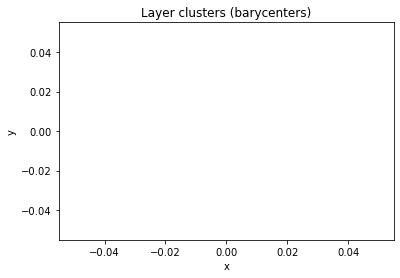

In [29]:
with uproot.open(out_path) as f:
    lc = f["LC"]
    df = lc.arrays(library="pd")

mask = (df["event"] == event_idx) & (df["layer"] == layer_idx)
plt.scatter(df["x"][mask], df["y"][mask], s=df["energy"][mask]*0.1)  # scale by energy
plt.xlabel("x"); plt.ylabel("y"); plt.title("Layer clusters (barycenters)")
plt.show()
